**Question answered:** Who are the users that never convert, and how do different behavioral segments differ?

**Key finding:** Browsers (97% of users) average 1.5 items per session with near-zero cart conversion, while Cart Abandoners (2%) show 28% view→cart but 0% cart→purchase — two structurally different problems requiring different interventions.

**Next:** See `reports/root_cause_analysis.md` for three root cause hypotheses and experiment designs.

# User Segmentation

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

base = os.path.join(os.getcwd(), '..')
session_df = pd.read_csv(os.path.join(base, 'data/processed/sessions.csv'))

In [10]:
session_df[session_df['session_duration_min'] == 0]

,visitorid,session_duration_min,events_in_session,reached_cart,reached_purchase,categories_browsed,items_viewed,session_number,items_viewed_bucket
649136,1,0.0,1,False,False,1,1.0,1,1
927578,3,0.0,1,False,False,1,1.0,1,1
1065370,4,0.0,1,False,False,0,1.0,1,1
1204848,5,0.0,1,False,False,1,1.0,1,1
1343608,6,0.0,1,False,False,1,1.0,3,1
...,...,...,...,...,...,...,...,...,...
566742,1407575,0.0,1,False,False,1,1.0,1,1
566743,1407576,0.0,1,False,False,1,1.0,1,1
566744,1407577,0.0,1,False,False,1,1.0,1,1
566745,1407578,0.0,1,False,False,1,1.0,1,1


In [9]:
session_df = session_df.sort_values('visitorid', ascending= True)

In [19]:
user_df = session_df.groupby('visitorid').agg(
    total_sessions= ('session_number', 'max'), 
    total_items_viewed= ('items_viewed', 'sum'), 
    avg_items_per_session= ('items_viewed', 'mean'), 
    distinct_categories_browsed= ('categories_browsed', 'nunique'), 
    made_cart= ('reached_cart', 'max'),
    made_purchase= ('reached_purchase', 'max')
).reset_index()

user_df.head()

,visitorid,total_sessions,total_items_viewed,avg_items_per_session,distinct_categories_browsed,made_cart,made_purchase
0,0,1,3.0,3.0,1,False,False
1,1,1,1.0,1.0,1,False,False
2,2,1,4.0,4.0,1,False,False
3,3,1,1.0,1.0,1,False,False
4,4,1,1.0,1.0,1,False,False


### User Segments

In [22]:
#User Segment Rules
decisive_buyers= (user_df['made_purchase'] == True) & (user_df['total_sessions'] <= 2)
researchers= (user_df['made_purchase'] == True) & (user_df['total_sessions'] > 2)
cart_abandoners= (user_df['made_cart'] == True) & (user_df['made_purchase'] == False)
browsers= user_df['made_cart']== False

conditions= [decisive_buyers, researchers, cart_abandoners, browsers]
segments= ['Decisive Buyer', 'Researcher', 'Cart Abandoner', 'Browser']
user_df['segment'] = np.select(conditions, segments, default= 'Other')

user_df.head()

,visitorid,total_sessions,total_items_viewed,avg_items_per_session,distinct_categories_browsed,made_cart,made_purchase,segment
0,0,1,3.0,3.0,1,False,False,Browser
1,1,1,1.0,1.0,1,False,False,Browser
2,2,1,4.0,4.0,1,False,False,Browser
3,3,1,1.0,1.0,1,False,False,Browser
4,4,1,1.0,1.0,1,False,False,Browser


### User Segment Investigation

In [23]:
user_segment_profile= user_df.groupby('segment').agg(
    users= ('visitorid', 'size'), 
    avg_items_viewed= ('total_items_viewed', 'mean'), 
    avg_total_sessions= ('total_sessions', 'mean'), 
    avg_distinct_categories_browsed= ('distinct_categories_browsed', 'mean')
)

user_segment_profile['pct_of_total_users'] = user_segment_profile['users'] / user_segment_profile['users'].sum()

user_segment_profile.head()

,users,avg_items_viewed,avg_total_sessions,avg_distinct_categories_browsed,pct_of_total_users
segment,,,,,
Browser,1368715,1.522830,1.215634,1.021262,0.972389
Cart Abandoner,27146,4.104767,2.029397,1.140389,0.019286
Decisive Buyer,7920,2.523485,1.328409,1.075505,0.005627
Researcher,3799,30.281653,8.478021,2.069755,0.002699


### Funnel Analysis

In [25]:
events_df = pd.read_csv(os.path.join(base, 'data/processed/events_enriched.csv'))
events_df.head()

,itemid,categoryid,parentid,available,timestamp,visitorid,event,transactionid
0,355908,1173.0,805.0,1.0,1433221332117,257597,view,NaN
1,248676,1231.0,901.0,1.0,1433224214164,992329,view,NaN
2,318965,NaN,NaN,NaN,1433221999827,111016,view,NaN
3,253185,914.0,226.0,0.0,1433221955914,483717,view,NaN
4,367447,491.0,679.0,0.0,1433221337106,951259,view,NaN


In [34]:
user_events_df = events_df.merge(user_df[['visitorid', 'segment']], how= 'inner', on= 'visitorid')
segment_event_group = user_events_df.groupby(['segment', 'event']).size().reset_index(name= 'count')
segment_event_pivot = segment_event_group.pivot_table(
    values= 'count', 
    index= 'segment', 
    columns= 'event',
    aggfunc= 'sum', 
    fill_value= 0
)

segment_event_pivot

event,addtocart,transaction,view
segment,,,
Browser,0,0,2334432
Cart Abandoner,41865,0,149126
Decisive Buyer,9945,9966,30082
Researcher,17522,12491,150672


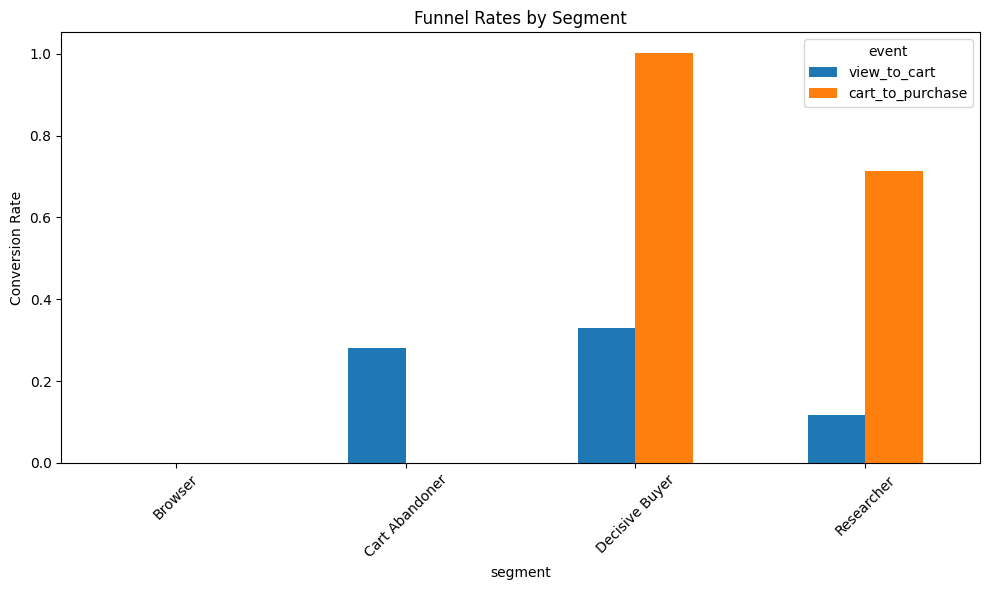

In [36]:
segment_event_pivot = segment_event_pivot.reset_index()

segment_event_pivot['view_to_cart'] = segment_event_pivot['addtocart'] / segment_event_pivot['view']
segment_event_pivot['cart_to_purchase'] = segment_event_pivot['transaction'] / segment_event_pivot['addtocart']

segment_event_pivot[['segment', 'view_to_cart', 'cart_to_purchase']].set_index('segment').plot(
    kind='bar', figsize=(10, 6), title='Funnel Rates by Segment'
)
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()